## **Modelling & Diagnosis**

Fitting and interrogating the seven-class classifier. The EDA established that
BENIGN is 82.96% of the data and the imbalance is 1,064:1, so the question here
is not "what accuracy do we get" but **which attack families does the model
actually catch, and which does it over-flag**.

Every number below comes from one stratified split, fixed at `RANDOM_STATE = 42`.
The test fold keeps the true class distribution and is never subsampled.

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(),"..", "src"))
import importlib

import numpy as np
import pandas as pd
from IPython.display import Image
from sklearn.metrics import confusion_matrix

import split_dataset as sd
import models as md
import evaluation as ev
import train as tr

for _m in (sd, md, ev, tr):
    importlib.reload(_m)

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 50)

**1. Split protocol and imbalance strategy**

A **stratified 80/20 split** so every class, including the 1,948-row Bot family,
appears in both folds in proportion.

The imbalance is handled in exactly one place: BENIGN is capped in the
**training fold only**. The test fold is left at the real distribution, so every
metric reported below is a metric on realistic traffic. Capping the test fold
instead would quietly inflate every precision figure in this notebook.

In [2]:
# LOAD THE SPLIT THAT EVERY NUMBER BELOW IS COMPUTED ON
split = sd.load_split(cap=tr.TRAIN_CAP)
names = ev.class_names(split)
feat = split["feature_names"]

train_counts = np.bincount(split["y_train"], minlength=len(names))
test_counts = np.bincount(split["y_test"], minlength=len(names))

print(f"train {len(split['y_train']):,} rows   "
      f"test {len(split['y_test']):,} rows   "
      f"{len(feat)} features")
print(f"BENIGN cap applied to the training fold: {tr.TRAIN_CAP:,}\n")

display(
    pd.DataFrame({
        "Class": names,
        "Train": train_counts,
        "Test": test_counts,
        "TestShare": (test_counts / test_counts.sum()).round(4),
    })
    .sort_values("Test", ascending=False)
    .reset_index(drop=True)
)

train 540,543 rows   test 499,587 rows   69 features
BENIGN cap applied to the training fold: 200,000



,Class,Train,Test,TestShare
0,BENIGN,200000,414451,0.8296
1,DoS,154984,38746,0.0776
2,DDoS,102411,25603,0.0512
3,PortScan,72555,18139,0.0363
4,BruteForce,7320,1830,0.0037
5,WebAttack,1714,429,0.0009
6,Bot,1559,389,0.0008


The cap is set at 200,000 rather than something smaller on purpose.
`subsample_majority_train` caps whichever class is *largest*, and DoS holds
~155k rows in the training fold. Capping BENIGN below that would hand the
majority to DoS, and the majority rung of the ladder below would then learn DoS
and score ~0.08 accuracy instead of the ~0.83 that makes the accuracy trap
visible.

**2. Why accuracy is the wrong headline**

Before fitting anything, establish what a model that has learned *nothing* scores.
`constant_baseline` reads the majority class straight off the test fold and
predicts it for every row, so no training decision can flatter it.

In [3]:
# THE "FLAG NOTHING" REFERENCE, COMPUTED RATHER THAN FITTED
always_benign = ev.constant_baseline(split["y_test"], names, cls="BENIGN")
display(pd.DataFrame([always_benign]).round(4))

,Model,Accuracy,MacroPrecision,MacroRecall,MacroF1
0,Always BENIGN,0.8296,0.1185,0.1429,0.1296


A detector that never raises an alarm is **~83% accurate** and catches zero
attacks. Macro-F1 collapses to near zero because it weights all seven classes
equally rather than letting BENIGN dominate. That is the reason macro-F1 and the
per-class table, not accuracy, carry the verdict from here on.

**3. Baseline ladder**

Three rungs, fit on the identical training fold and scored identically:

- **Majority** - the control. Learns one class and predicts it forever.
- **Logistic regression** - a linear reference, wrapped in a `StandardScaler`
  fit inside the pipeline so it never sees test rows. The EDA found 30 of 69
  features with `|skew| > 10` and ranges spanning ~9 orders of magnitude, so an
  unscaled linear model would be dominated by whichever feature is measured in
  microseconds.
- **XGBoost** - the model under test. Scale-invariant, so it takes raw features.

The gap between rungs is what says whether the problem needed a non-linear model
at all.

In [4]:
# MAJORITY -> LOGISTIC -> XGBOOST, ALL ON THE SAME SPLIT
ladder = ev.baseline_ladder(split)
display(ladder["table"])

Majority (BENIGN)    macro-F1 0.1296   accuracy 0.8296   (0s)


/mnt/c/Users/lixin/portfolio/cybersecurity_project/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic regression  macro-F1 0.6375   accuracy 0.9604   (37s)


XGBoost              macro-F1 0.9648   accuracy 0.9988   (32s)


,Model,Accuracy,MacroPrecision,MacroRecall,MacroF1,FitSeconds
0,Majority (BENIGN),0.8296,0.1185,0.1429,0.1296,0.0
1,Logistic regression,0.9604,0.6130,0.7092,0.6375,36.5
2,XGBoost,0.9988,0.9442,0.9950,0.9648,32.0


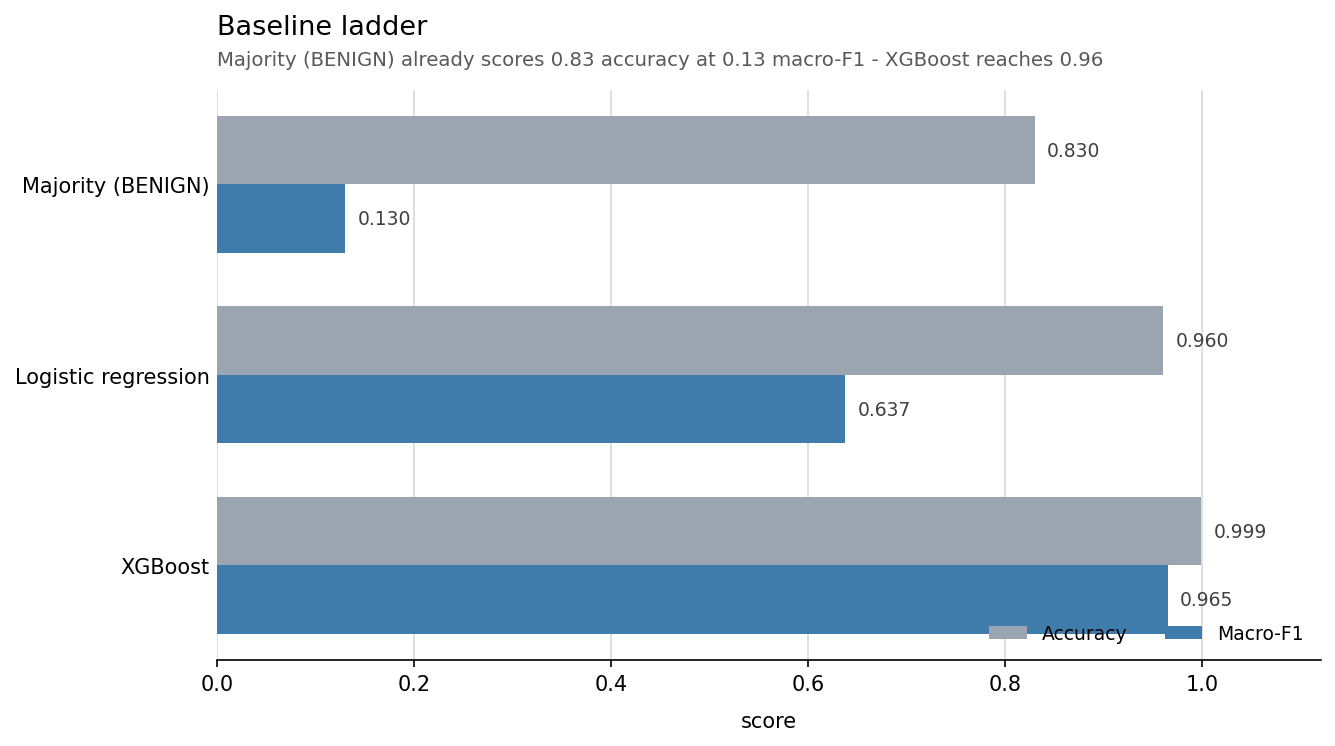

In [5]:
Image(ev.plot_baseline_ladder(ladder["table"]))

Two things to read off the ladder.

**The accuracy column barely discriminates.** Every rung, including the control
that has learned nothing, sits above 0.82; the linear rung reaches 0.96 while
catching well under half of what XGBoost catches. Macro-F1 separates the three
cleanly. That is the accuracy trap on real numbers rather than asserted.

**The logistic rung did not converge** - `lbfgs` hit the 200-iteration limit and
warned. Raising `max_iter` would move its score somewhat, but not by the ~0.33
macro-F1 that separates it from XGBoost. It is kept as a reference point, not
tuned as a candidate, so the non-convergence is recorded rather than fixed.

The XGBoost rung above was refit here so all three rungs share one fit
procedure. It should be identical to the model `src/train.py` already persisted,
same seed, same cap, same split. Worth confirming rather than assuming, because
the saved model stores class *indices* and a mismatched class order would be
silent.

In [6]:
# PROVENANCE: THE PERSISTED MODEL IS THIS EXACT FIT
meta = tr.load_metadata()
xgb = ladder["models"]["xgboost"]
xgb_pred = ladder["predictions"]["xgboost"]
saved_pred = md.predict_in_chunks(tr.load_model(), split["X_test"])

print(f"persisted: cap={meta['cap']:,}  rows={meta['rows']:,}  "
      f"features={meta['features']}  fit={meta['fit_seconds']}s")
print(f"class order matches:    {meta['classes'] == names}")
print(f"predictions identical:  {np.array_equal(saved_pred, xgb_pred)}")

persisted: cap=200,000  rows=540,543  features=69  fit=33.7s
class order matches:    True
predictions identical:  True


**4. Per-class results and the confusion matrix**

Macro-F1 is one number averaged over seven classes; the per-class table is where
the model's real behaviour lives. Two failure modes matter and they are not
symmetric:

- **Low recall** - the attack was missed. A detector that misses attacks is not
  a detector.
- **Low precision** - benign traffic was flagged as an attack. This is the
  failure mode that gets a real IDS switched off by the analysts drowning in its
  alerts.

In [7]:
# WHERE THE MACRO AVERAGE ACTUALLY COMES FROM
report = ev.per_class_report(split["y_test"], xgb_pred, names)
display(report)

,Class,Precision,Recall,F1,Support
0,BENIGN,1.000,0.999,0.999,414451
1,DoS,0.997,1.000,0.998,38746
2,DDoS,0.999,1.000,1.000,25603
3,PortScan,0.989,0.999,0.994,18139
4,BruteForce,0.999,1.000,0.999,1830
5,WebAttack,0.979,0.991,0.985,429
6,Bot,0.646,0.977,0.778,389


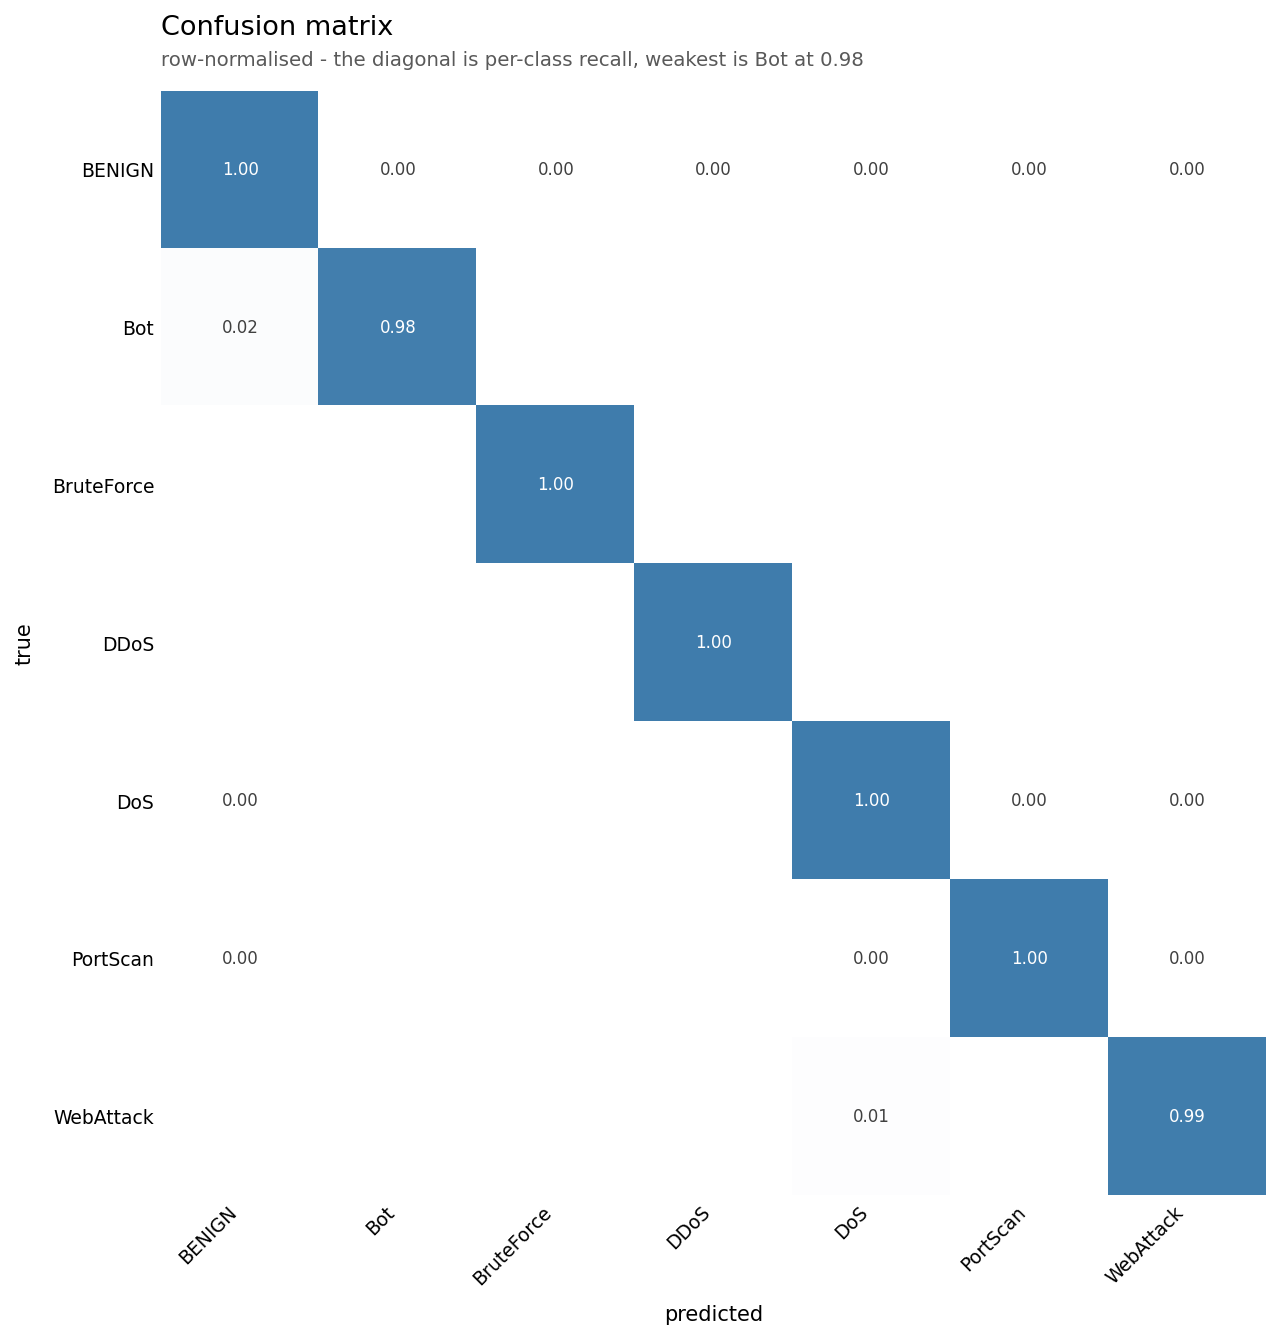

In [8]:
Image(ev.plot_confusion_matrix(split["y_test"], xgb_pred, names))

Row-normalising makes the diagonal read as **recall**, and by that measure the
model looks close to flawless - every row is 0.98 or better.

That is exactly the limitation of this view. Recall is the failure mode this
model does *not* have. The precision problem is a **column** effect: BENIGN rows
landing in an attack column. Row-normalised against 414,451 BENIGN rows, a leak
of 208 renders as `0.00` and disappears. The same matrix in raw counts puts it
back on screen.

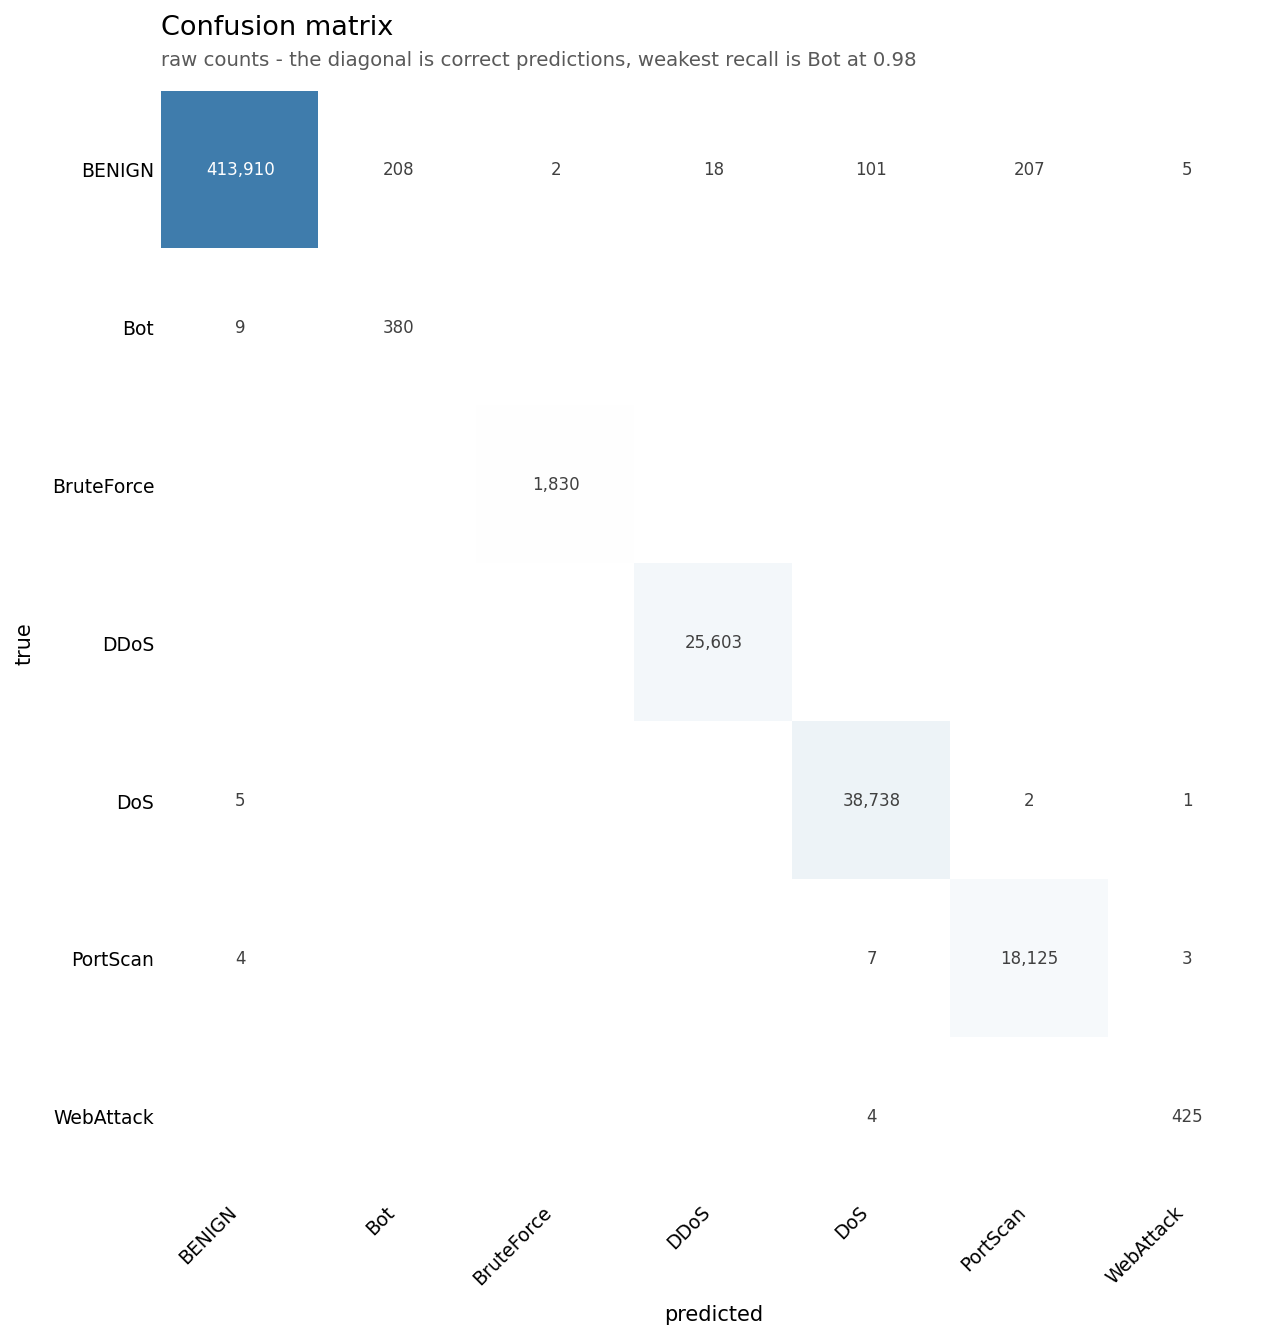

In [9]:
# THE SAME MATRIX IN COUNTS - WHERE THE PRECISION STORY IS ACTUALLY VISIBLE
Image(ev.plot_confusion_matrix(split["y_test"], xgb_pred, names,
                               normalize=False,
                               save_name="confusion_matrix_counts.png"))

In [10]:
# THE LARGEST OFF-DIAGONAL CELLS, AS A SHARE OF THE TRUE CLASS
display(ev.top_confusions(split["y_test"], xgb_pred, names, top=6))

,TrueClass,PredictedClass,Count,ShareOfTrueClass
0,Bot,BENIGN,9,0.0231
1,WebAttack,DoS,4,0.0093
2,BENIGN,Bot,208,0.0005
3,BENIGN,PortScan,207,0.0005
4,PortScan,DoS,7,0.0004
5,BENIGN,DoS,101,0.0002


In [11]:
# FALSE POSITIVES AND FALSE NEGATIVES IN RAW COUNTS
cm = confusion_matrix(split["y_test"], xgb_pred, labels=range(len(names)))
errors = pd.DataFrame({
    "Class": names,
    "Support": cm.sum(axis=1),
    "FalsePositives": cm.sum(axis=0) - np.diag(cm),
    "FalseNegatives": cm.sum(axis=1) - np.diag(cm),
})
errors["FPPerTruePositive"] = (
    errors["FalsePositives"] / np.maximum(np.diag(cm), 1)
).round(3)
display(errors.sort_values("FalsePositives", ascending=False).reset_index(drop=True))

,Class,Support,FalsePositives,FalseNegatives,FPPerTruePositive
0,PortScan,18139,209,14,0.012
1,Bot,389,208,9,0.547
2,DoS,38746,112,8,0.003
3,BENIGN,414451,18,541,0.000
4,DDoS,25603,18,0,0.001
5,WebAttack,429,9,4,0.021
6,BruteForce,1830,2,0,0.001


In [12]:
# HOW MUCH OF THE MACRO-PRECISION GAP IS A SINGLE CLASS
weakest = report.sort_values("Precision").iloc[0]["Class"]
macro_p = report["Precision"].mean()
macro_p_ex = report.loc[report["Class"] != weakest, "Precision"].mean()

print(f"macro precision, all {len(names)} classes:  {macro_p:.3f}")
print(f"macro precision excluding {weakest}:{'':<7} {macro_p_ex:.3f}")
print(f"every class except {weakest} has precision >= "
      f"{report.loc[report['Class'] != weakest, 'Precision'].min():.3f}")

macro precision, all 7 classes:  0.944
macro precision excluding Bot:        0.994
every class except Bot has precision >= 0.979


**One class is the entire macro-precision story.** Every family except Bot holds
precision at or above 0.979. Drop Bot and macro precision goes from 0.944 to
0.994, which means the headline gap against macro recall (0.995) is one class
rather than a systemic bias.

The mechanism is visible by reading the two error tables together. Bot and
PortScan absorb almost exactly the same number of false positives out of BENIGN
- 208 and 207. For PortScan, sitting on 18,139 true rows, that is noise:
precision 0.989. For Bot, sitting on 389, it is fatal: 208 false alarms against
380 correct ones, precision 0.646. **Identical absolute error, opposite
consequence.**

Note how small the leak actually is. Only 0.05% of BENIGN rows are misrouted to
Bot. But BENIGN outnumbers Bot by more than 1,000:1, so a rounding error on the
majority class becomes the minority class's dominant failure mode. The
imbalance ratio from the EDA is not just a training-time problem to be capped
away; it sets what minority-class precision can possibly be at evaluation time.

**5. Which features drive the predictions**

Gain-based importance says which features the model *leaned on*, not which
features cause an attack. Two caveats carried forward from the EDA:

- 6 feature pairs were confirmed to be **exact aliases** on the full data
  (`TotalFwdPackets` / `SubflowFwdPackets` and friends). Gain is split between
  the mirrors, so each is understated relative to the quantity it measures.
- `InitWinBytesForward` tiers classes by **OS/tool default TCP window size**,
  not by anything conceptually about the attack. If it ranks highly, that is
  evidence of tool fingerprinting, not of a generalisable signal.

In [13]:
# GAIN-BASED IMPORTANCE
imp = ev.feature_importance(xgb, feat)
display(imp.head(15))

,Feature,Importance
0,IdleMean,0.174445
1,BwdPacketLengthMin,0.116703
2,ActDataPktFwd,0.097688
3,BwdPacketLengthStd,0.092655
4,PshFlagCount,0.065498
5,TotalLengthOfFwdPackets,0.061641
6,AveragePacketSize,0.055297
7,FwdPacketLengthStd,0.050735
8,TotalLengthOfBwdPackets,0.043627
9,TotalBackwardPackets,0.032774


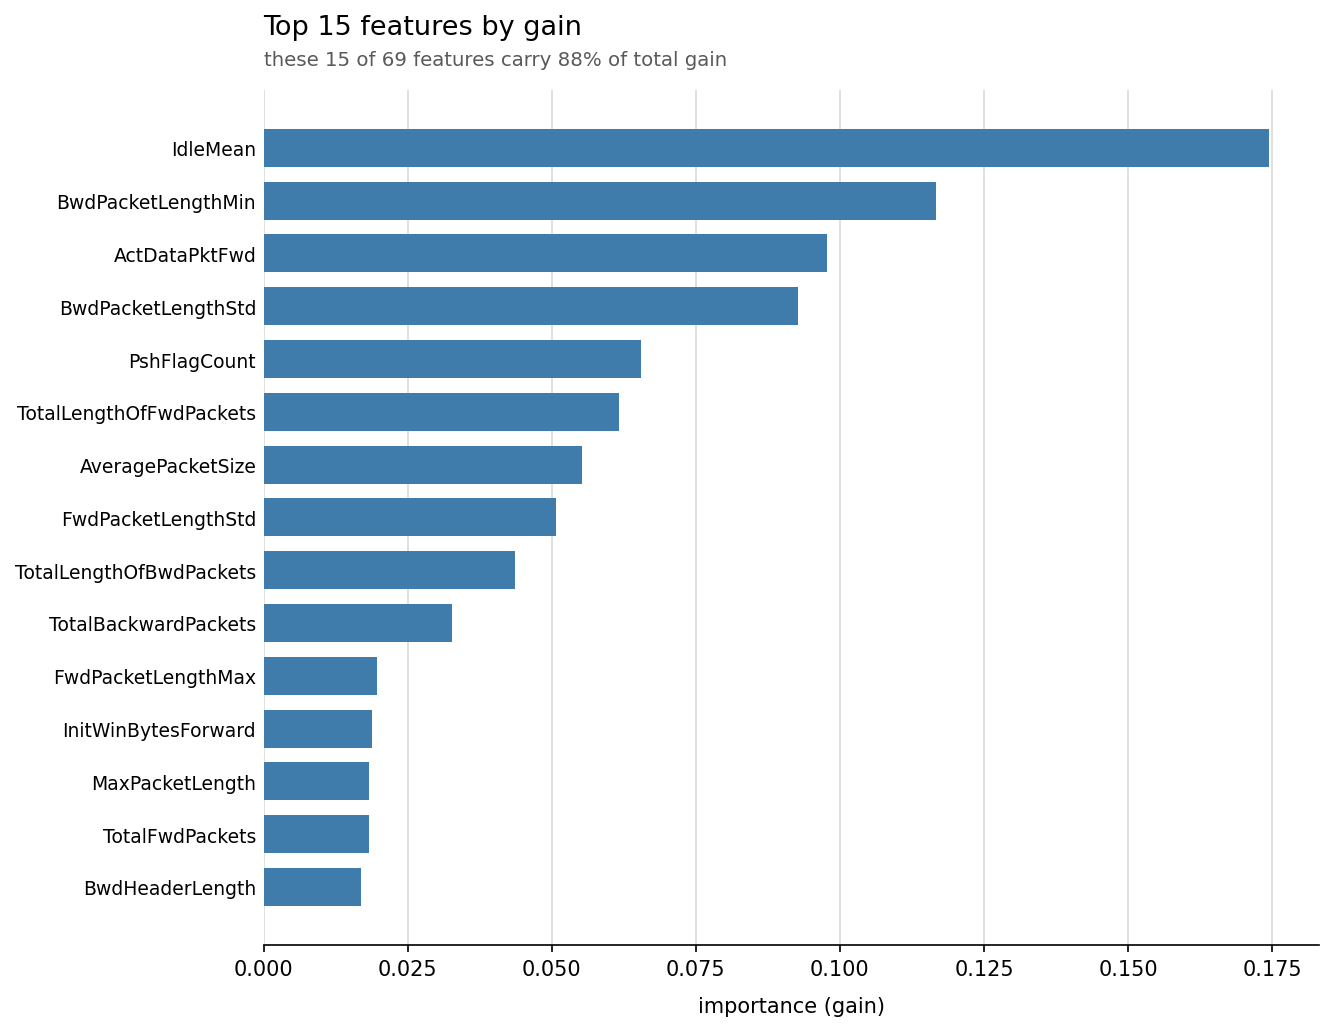

In [14]:
Image(ev.plot_feature_importance(imp))

In [15]:
# WHERE THE FEATURE THE EDA FLAGGED ACTUALLY LANDED
iwb = imp.index[imp["Feature"] == "InitWinBytesForward"][0] + 1
print(f"InitWinBytesForward ranks {iwb} of {len(imp)} "
      f"at {imp.iloc[iwb - 1]['Importance']:.3f} gain")
print(f"top 15 features carry {imp.head(15)['Importance'].sum():.0%} of total gain")

InitWinBytesForward ranks 12 of 69 at 0.019 gain
top 15 features carry 88% of total gain


`IdleMean` leads at 17% of total gain, with backward packet-length statistics
and `ActDataPktFwd` behind it.

Worth recording what did **not** happen. `InitWinBytesForward` - the feature the
EDA singled out as tiering classes by OS/tool default TCP window size - ranks
12th at 1.9% of gain. The model is not leaning on it nearly as hard as the EDA
warned it might, which weakens that one specific piece of evidence for tool
fingerprinting.

It does not clear the model, and this is worth being careful about. Gain is
split across the six confirmed alias pairs, so any single feature's share
understates the quantity it measures. More importantly, a within-capture split
cannot separate attack signal from tool signature regardless of which feature
ranks first - low importance on one flagged feature is weak evidence against a
concern that the experimental design cannot test in the first place.

**6. Stability**

A single 80/20 split can flatter or penalise a model by luck of the partition.
Stratified 5-fold cross-validation on the capped training fold shows whether the
headline macro-F1 is a property of the model or of one lucky split. A tight
spread across folds is the evidence; the mean alone is not.

In [16]:
# STRATIFIED 5-FOLD ON THE CAPPED TRAINING FOLD
cv = ev.cross_val_macro_f1(split["X_train"], split["y_train"])
print(f"\nmacro-F1 {cv['mean']:.4f} +/- {cv['std']:.4f} "
      f"across {len(cv['scores'])} folds")

fold 1/5  macro-F1 0.9917


fold 2/5  macro-F1 0.9906


fold 3/5  macro-F1 0.9911


fold 4/5  macro-F1 0.9910


fold 5/5  macro-F1 0.9937

macro-F1 0.9916 +/- 0.0011 across 5 folds


**The cross-validation score is higher than the test score, and that is a
property of the folds rather than an improvement.** 5-fold macro-F1 comes out at
0.9916 against 0.9648 on the held-out test fold.

The folds are drawn from the *capped* training set, where BENIGN has already
been cut to 200,000 rows. Inside a fold the BENIGN:Bot ratio is roughly 129:1
instead of the 1,065:1 that holds in real traffic, so there is an order of
magnitude less BENIGN available to leak into Bot, and Bot's precision - the one
number dragging macro-F1 down - recovers.

So this section establishes exactly one thing: the ±0.0011 spread shows the fit
is **stable under resampling** and the single-split result is not a lucky
partition. The *level* is optimistic and must not be quoted as the headline.
**0.9648 on the uncapped test fold is the number that reflects real traffic.**

It also cannot show the model generalises to traffic it has never seen, because
every fold is drawn from the same week of CIC-IDS2017 and carries the same tool
fingerprints.

**7. Summary**

In [17]:
best = ladder["table"].loc[ladder["table"]["MacroF1"].idxmax()]
logistic_f1 = ladder["table"].iloc[1]["MacroF1"]
weak_recall = report.sort_values("Recall").iloc[0]
weak_prec = report.sort_values("Precision").iloc[0]

err = errors.set_index("Class")
bot, ps = weak_prec["Class"], "PortScan"

summary = pd.DataFrame(
    [
        ("Accuracy is not the metric",
         f"Always-BENIGN scores {always_benign['Accuracy']:.3f} accuracy at "
         f"{always_benign['MacroF1']:.3f} macro-F1",
         "Report macro-F1 and the per-class table; accuracy is quoted only to show the trap"),
        ("Non-linearity earns its place",
         f"Logistic {logistic_f1:.3f} macro-F1 vs XGBoost {best['MacroF1']:.3f}",
         "Keep the tree model; the linear rung is a reference, not a tuned candidate"),
        ("Attacks are caught",
         f"macro recall {best['MacroRecall']:.3f}; weakest is "
         f"{weak_recall['Class']} at {weak_recall['Recall']:.3f}",
         "The dominant failure mode is false alarms, not misses"),
        ("One class sets macro precision",
         f"{bot} precision {weak_prec['Precision']:.3f}; macro precision "
         f"{macro_p:.3f} -> {macro_p_ex:.3f} without it",
         f"The macro precision/recall gap is {bot} alone, not a systemic bias"),
        ("Same error, opposite cost",
         f"{int(err.loc[bot, 'FalsePositives']):,} false positives into {bot} "
         f"({int(err.loc[bot, 'Support']):,} true rows) vs "
         f"{int(err.loc[ps, 'FalsePositives']):,} into {ps} "
         f"({int(err.loc[ps, 'Support']):,} true rows)",
         "Minority-class precision is set by the size of the BENIGN pool, not by the class"),
        ("Stability, with a caveat",
         f"5-fold {cv['mean']:.4f} +/- {cv['std']:.4f} on the capped fold vs "
         f"{best['MacroF1']:.4f} on the uncapped test fold",
         "Spread shows a stable fit; the level is optimistic because folds inherit the cap"),
        ("Tool fingerprinting unresolved",
         f"Top gain {imp.iloc[0]['Feature']}; InitWinBytesForward only ranks "
         f"{iwb} at {imp.iloc[iwb - 1]['Importance']:.3f}",
         "Importance does not implicate the flagged feature, but the design cannot clear it"),
    ],
    columns=["Finding", "Evidence", "Reading"],
)

with pd.option_context("display.max_colwidth", None):
    display(summary)

,Finding,Evidence,Reading
0,Accuracy is not the metric,Always-BENIGN scores 0.830 accuracy at 0.130 macro-F1,Report macro-F1 and the per-class table; accuracy is quoted only to show the trap
1,Non-linearity earns its place,Logistic 0.637 macro-F1 vs XGBoost 0.965,"Keep the tree model; the linear rung is a reference, not a tuned candidate"
2,Attacks are caught,macro recall 0.995; weakest is Bot at 0.977,"The dominant failure mode is false alarms, not misses"
3,One class sets macro precision,Bot precision 0.646; macro precision 0.944 -> 0.994 without it,"The macro precision/recall gap is Bot alone, not a systemic bias"
4,"Same error, opposite cost","208 false positives into Bot (389 true rows) vs 209 into PortScan (18,139 true rows)","Minority-class precision is set by the size of the BENIGN pool, not by the class"
5,"Stability, with a caveat",5-fold 0.9916 +/- 0.0011 on the capped fold vs 0.9648 on the uncapped test fold,Spread shows a stable fit; the level is optimistic because folds inherit the cap
6,Tool fingerprinting unresolved,Top gain IdleMean; InitWinBytesForward only ranks 12 at 0.019,"Importance does not implicate the flagged feature, but the design cannot clear it"


**Limitations**

- **Within-capture evaluation.** Train and test are random partitions of one
  week of traffic, so each attack tool's fingerprint appears on both sides. The
  scores partly measure tool recognition rather than proven generalisation to
  novel attacks. Cross-dataset evaluation against CSE-CIC-IDS2018 is the honest
  next test, and no score in this notebook substitutes for it.
- **Bot detection is not deployable as it stands.** At 0.646 precision, roughly
  one in three Bot alerts is a benign flow. Recall is 0.977, so the signal is
  there; the problem is the false-alarm rate against a BENIGN pool 1,065 times
  larger. Threshold tuning on the Bot class, or a cost-sensitive objective,
  is the obvious next experiment and is not attempted here.
- **Two attack families are out of scope.** Infiltration (36 rows) and
  Heartbleed (11 rows) were excluded during preprocessing as too rare to train
  or evaluate on. The model cannot detect them and does not claim to.
- **No hyperparameter search.** Sensible XGBoost defaults only, so the reported
  score is a floor for this model class rather than a tuned result.
- **`DestinationPort` is fed as an ordinal float** across 53,791 distinct
  values, which is wrong in principle; the EDA kept it because the top three
  ports carry ~75% of traffic. Top-K categorical encoding is the fix.